# Guide to the Multi-Slit UVMOS ETC

Jade Yeung, July 2026

## 1. Importing Packages

This section shows how to import the packages you need to be able to use the ETC.  For certain plots you may need to use $\verb+matplotlib.pyplot+$.  Then you need to import $\verb+castor_etc+$ from the CASTOR container on CANFAR and from that import $\verb+telescope+$, $\verb+background+$, $\verb+sources+$, and $\verb+spectrum+$.  The multi-slit version of the UVMOS ETC is currently not available on CANFAR, so to use it you need to download it from the CASTOR-ETC Github and then upload it in CANFAR.  Then you need to import all the functions.

In [1]:
import matplotlib.pyplot as plt

In [2]:
import castor_etc # Import the castor etc from CASTOR container on CANFAR
from castor_etc import telescope, background, sources, spectrum, scene
from uvmos_spectroscopy import * 

Please note the archive will not be accessible on 29 July from 11 to 13 CEST, for maintenance purposes. Apologies for the inconveniences.


## 2. Setting Up the ETC

In this section, you will set up the UVMOS ETC.  

First you need to define a telescope and background object.  The default telescope object is set to CASTOR's parameters, but you can change the parameters to represent any telescope.

In [3]:
### Define a telescope object and a background object

my_telescope=telescope.Telescope()
my_background=background.Background()

Now you need to create a Scene object.  I did change the scene class so now there is an optional paramter called source_name.  You enter a name for the source.  This is just so that the uvmos etc knows which spectrum to use. 

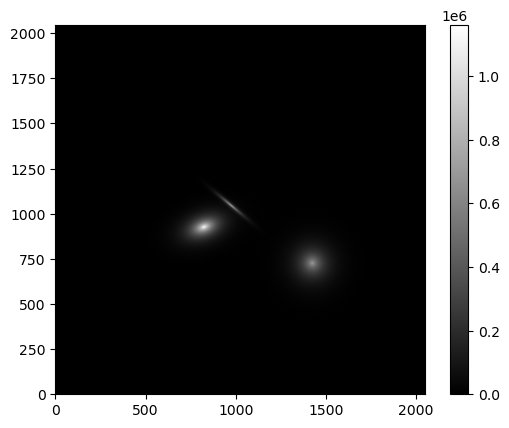

In [4]:
### Define source objects

# Make 3 galaxy sources with varying magnitude, effective radius, axial ratio, and rotation.
source_1 = sources.GalaxySource(r_eff = 10, n = 1, axial_ratio = 0.6, rotation = 20)
source_1.use_pickles_spectrum("g0v")
source_1.norm_to_AB_mag(-1)

source_2 = sources.GalaxySource(r_eff = 10, n = 1, axial_ratio = 1.0)
source_2.use_pickles_spectrum("b0v")
source_2.norm_to_AB_mag(0)

source_3 = sources.GalaxySource(r_eff = 9, n = 1, axial_ratio = 0.1, rotation = -40)
source_3.use_pickles_spectrum("a0v")
source_3.norm_to_AB_mag(1.5)

# Make a point source
source_4 = sources.PointSource()
source_4.use_pickles_spectrum("b0v")
source_4.norm_to_AB_mag(10)

# Define and add the four sources to the scene
my_scene = Scene(my_telescope)
my_scene.addSource(source_1, mag = -1, delta_x = -200, delta_y = -100, source_name = "source_1")
my_scene.addSource(source_2, mag = -1, delta_x = 400, delta_y = -300, source_name = "source_2")
my_scene.addSource(source_3, mag = 1.5, delta_x = -50, delta_y = 20, source_name = "source_3")
my_scene.addSource(source_4, mag = 10, delta_x = 0, delta_y = 0, source_name = "source_4")

scene_array = my_scene.displayScene(my_telescope, "uv") # Display the scene

plt.imshow(scene_array, cmap = "gray", origin = "lower")
plt.colorbar()
plt.show()

If there are multiple sources, you need to specify coordinates for each source in pixel coordinates. 

After specifying the coordinates, you can initialize the UVMOS ETC using the $\verb+UVMOS_Spectroscopy()+$ function.  $\verb+case+$ determines which orientation of the DMD and the dispersion.  Case 1 has the DMD at a $45^\circ$ angle relative to the detector.  Case 2 has the DMD aligned with the detector, but with the dispersion at a $45^\circ$ angle.

One thing that needs to be updated is the size of the slits.  This will not affect how you use the ETC so just keep it in mind when using that some of the numbers are a bit outdated.

In [5]:
### Define coordinates and slit orientations

theta_list = [0, 80, 45, 45] # The orientation of the slit

deltaXY = np.array([[-190, -100], [405, -295], [-50, 20], [0, 0]]) # pixel coordinates for the center of each slit

source_names = ["source_1", "source_2", "source_3", "source_4"] # create a list of source names.  This must match source_name in the scene class.

# Initialize the UVMOS ETC
uvmos_etc=UVMOS_Spectroscopy(my_telescope, my_scene, my_background, deltaXY = deltaXY, theta = theta_list, case = 1, source_name = source_names)
# Case determines which orientation of the DMD to use.  See Yeung+ 2026 for more details.

## 3. Using the ETC

The $\texttt{show\_slits()}$ function displays the location of each slit on the detector.  The slit size is very small compared to the size of the detector, so they might be difficult to see.  The slits are in red.  If the value of a pixel is negative, it means that it is outside of the field of view of the DMD.

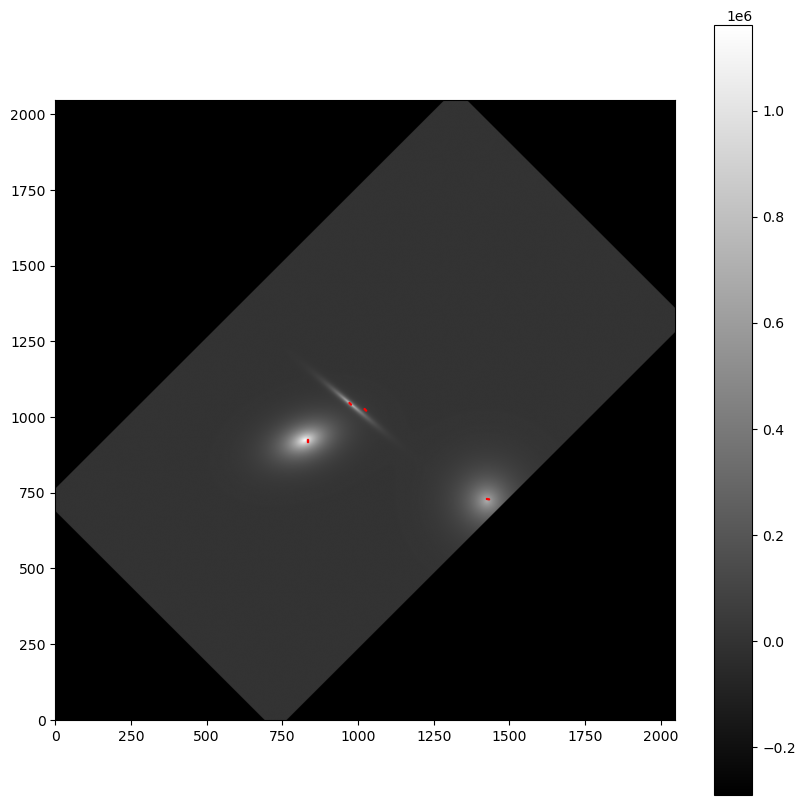

In [6]:
### Displaying the slits on the detector

uvmos_etc.show_slits()

The function $\verb+calc_slit_transmission()+$ displays the slit transmission.  This is how much of the point source's light passes through the slit.  This function does not show the spectrographic throughput.  This function is not required to be called to get the SNR or the exposure time (or any of the other plots), but if you want to see the transmission, you need to set $\verb+print_transmission_fact=True+$.

In [7]:
### Displaying the slit transmission

fractional_slit_transmission = uvmos_etc._calc_slit_transmission(print_transmission_fact=True)

Fractional slit transmission (2D estimation) 0.11961436926334451
Fractional slit loss (2D estimation) 0.8803856307366555
Fractional slit transmission (2D estimation) 0.20217547996813465
Fractional slit loss (2D estimation) 0.7978245200318653
Fractional slit transmission (2D estimation) 0.2378130478108811
Fractional slit loss (2D estimation) 0.7621869521891189
Fractional slit transmission (2D estimation) 0.2794798865480278
Fractional slit loss (2D estimation) 0.7205201134519722


The function $\verb+show_source_pix_weights()+$ shows the pixel weights for each source.

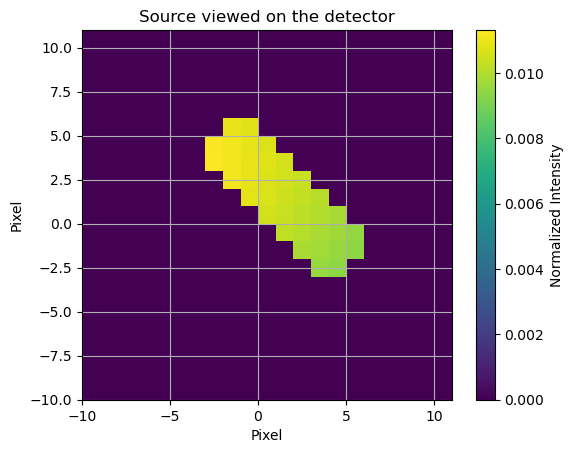

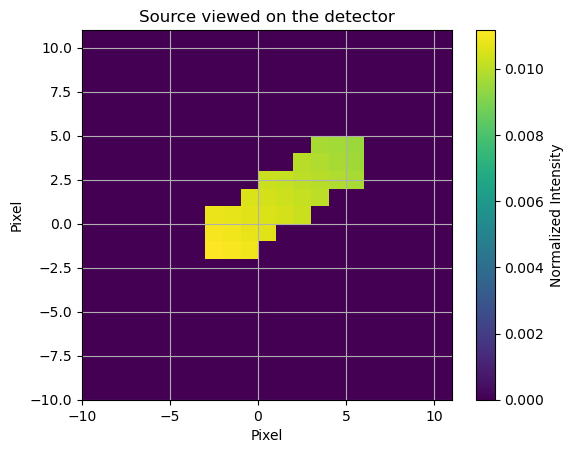

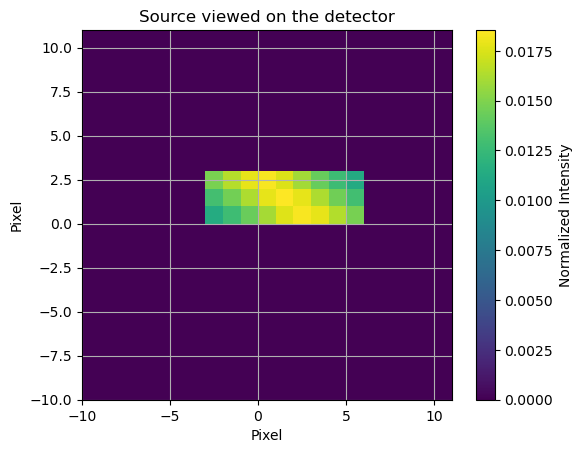

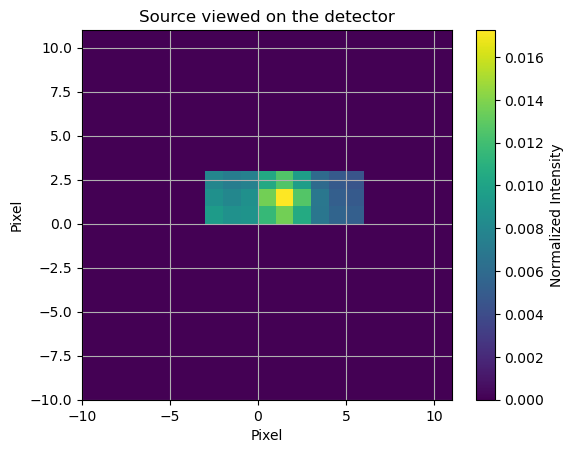

In [8]:
### Displaying the pixel weights

uvmos_etc.show_source_pix_weights()

The function $\verb+show_slit_image()+$ is a function that returns the slit image with the source light smeared out over a range of wavelengths and the center pixels of each source.  If you want to display the slit image, you need to plot it.  The parameter $\verb+wavelength+$ is the desired wavelength in nanometers.  Note that this is in different units from the wavelength you need to specify to get the SNR and the exposure time, which is in angstroms.

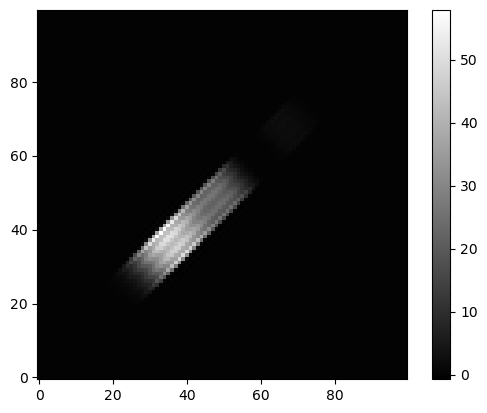

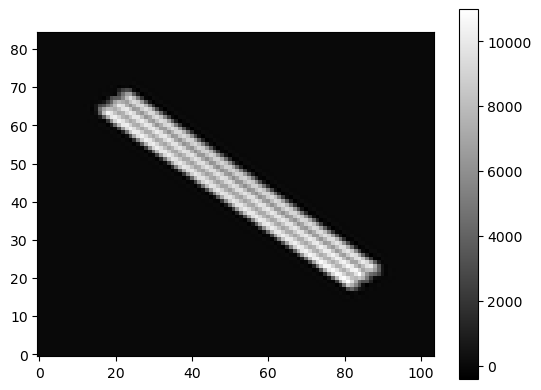

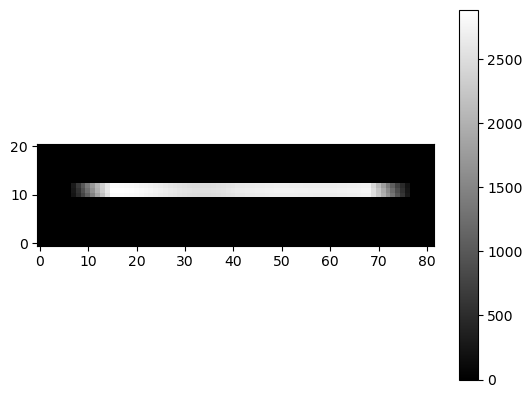

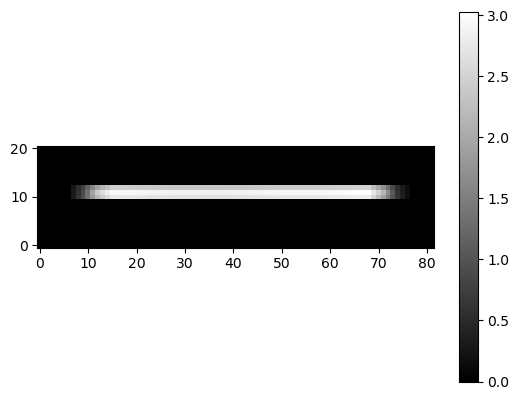

In [15]:
### Displaying the smeared out slits

# Need to specify a wavelength
wavelength = 200 # nm

slit_images, center_pixels = uvmos_etc.show_slit_image(wavelength) 
# slit_images are the images of the smeared out slit and center pixels are the center pixel of each source.

# Plot each image
for slit in slit_images:
    plt.imshow(slit, cmap = "gray", origin = "lower")
    plt.colorbar()
    plt.show()

The function $\verb+calc_source_CASTORSpectrum()+$ calculates the spectrum and returns the wavelengths, the spectra, the number of pixels used in the spectrum extraction, and the detector arrays. 

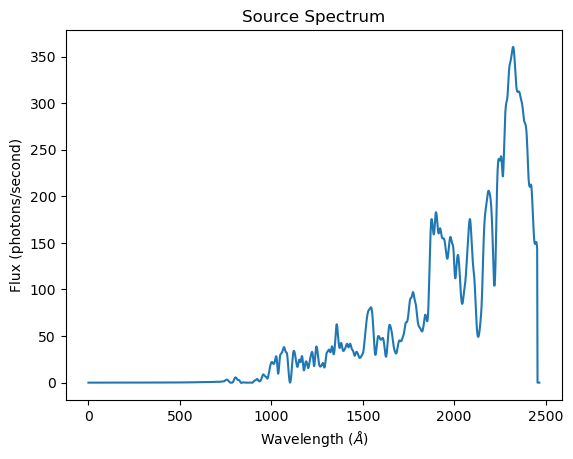

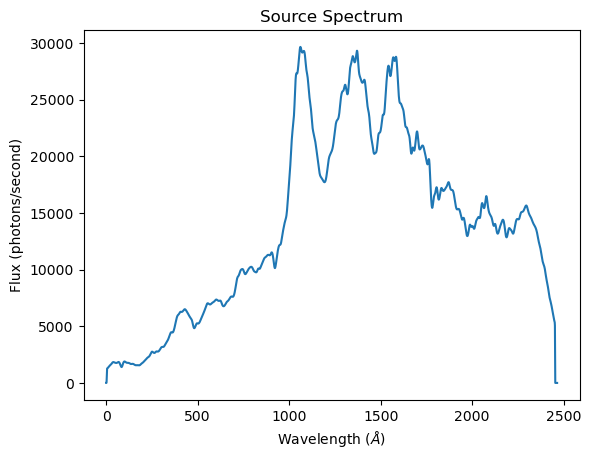

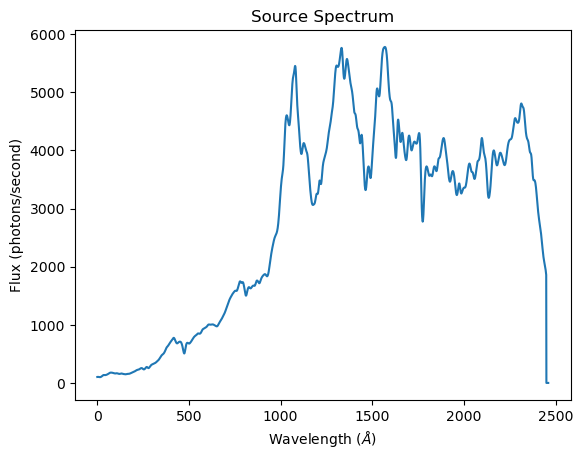

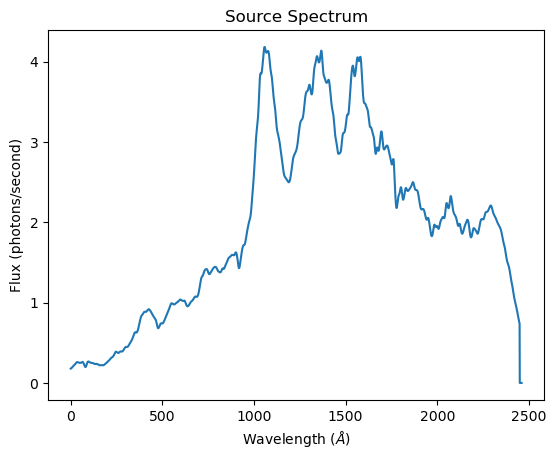

In [10]:
### Getting the source spectrum

uvmos_etc.calc_source_CASTORSpectrum()

# After you run this function, you can get:
# uvmos_etc.waves_CASTORSpectrum_list
# uvmos_etc.source_CASTORSpectrum_list
# uvmos_etc.source_extracted_numpixs_list
# uvmos_etc.source_detector_list

for i in uvmos_etc.source_CASTORSpectrum_list:
    plt.plot(i)
    plt.title("Source Spectrum")
    plt.xlabel(r"Wavelength ($\AA$)")
    plt.ylabel("Flux (photons/second)")
    plt.show()

The function $\verb+calc_background_CASTORSpectrum()+$ calculates the background spectrum and returns the wavelengths, the background spectra, and the number of pixels used in the spectrum extraction.  Here the background spectrum for each source is the same because I did not specify a spectra for each background object.  

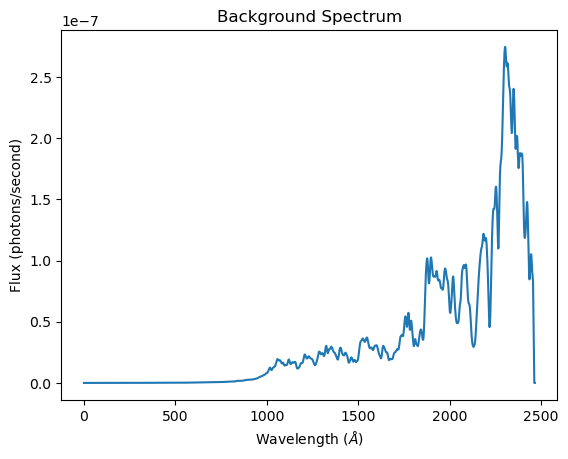

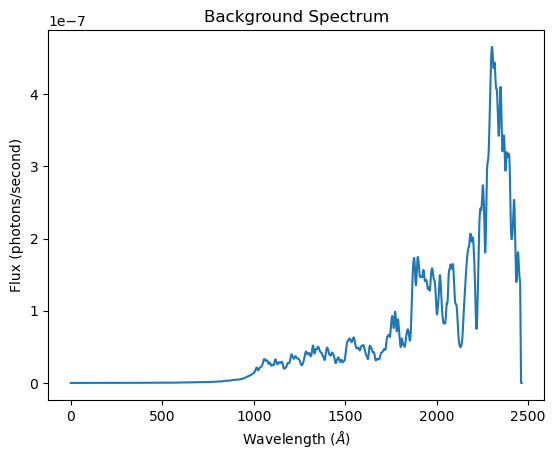

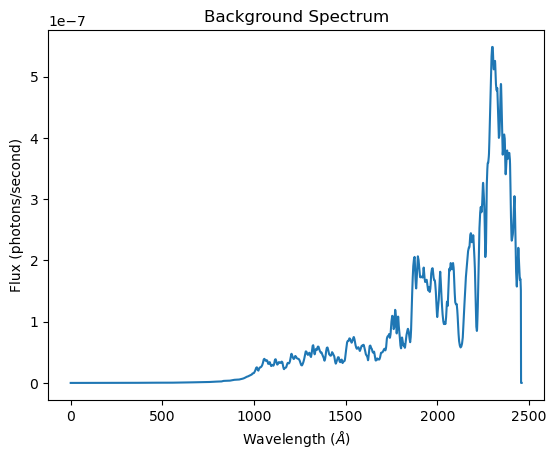

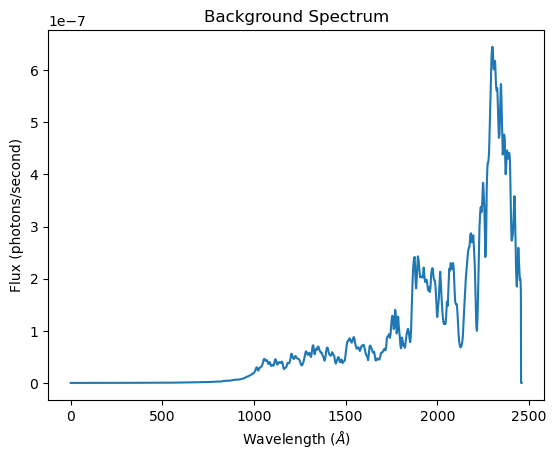

In [11]:
### Getting the background transmission

uvmos_etc.calc_background_CASTORSpectrum() # Calculate the background spectrum

# This function gets:
# uvmos_etc.waves_CASTORSpectrumBackground_list
# uvmos_etc.background_CASTORSpectrum_list
# uvmos_etc.background_extracted_numpixs_list

for i in uvmos_etc.background_CASTORSpectrum_list:
    plt.plot(i)
    plt.title("Background Spectrum")
    plt.xlabel(r"Wavelength ($\AA$)")
    plt.ylabel("Flux (photons/second)")
    plt.show()

The function $\verb+calc_t_from_snr()+$ is a function that returns the exposure time in seconds given a desired SNR and a wavelength.  Note that wavelength here is in angstroms not nanometers.  If you don't care about any of the previous plots, and only care about finding the exposure time, then this is the only function you have to run in Section 3.

In [12]:
### Finding the exposure time for a given SNR

desired_snr = 10
wavelength = 2000 # angstroms

t = uvmos_etc.calc_t_from_snr(desired_snr, wavelength)

for i in t:
    print("The exposure time needed for an SNR of", desired_snr, "is", round(i, 3), "s")

The exposure time needed for an SNR of 10 is 1674.346 s
The exposure time needed for an SNR of 10 is 0.488 s
The exposure time needed for an SNR of 10 is 2.961 s
The exposure time needed for an SNR of 10 is 3495.108 s


The function $\verb+calc_snr_from_t+$ returns a SNR for a given exposure time and wavelength.  Note that similarly to the previous function, wavelength is in angstrom, not nanometers.  Again, if you only want the exposure time, you can skip running all of the previous functions in Section 3 and only run this function.

In [13]:
### Finding the SNR for a given exposure time

exposure_time = 100 # seconds
wavelength = 2000 # angstroms

snr = uvmos_etc.calc_snr_from_t(exposure_time, wavelength)

for i in snr:
    print("The snr for an exposure time of", exposure_time, "seconds is", round(i, 3))

The snr for an exposure time of 100 seconds is 0.608
The snr for an exposure time of 100 seconds is 891.79
The snr for an exposure time of 100 seconds is 259.77
The snr for an exposure time of 100 seconds is 0.294


### 4. View UVMOS Properties

This section focuses on functions that display plots about the properties of the UVMOS.  It is optional to run any of these functions.

The first function in this section, $\verb+showTransmission()+$ displays the spectrographic throughput of CASTOR.

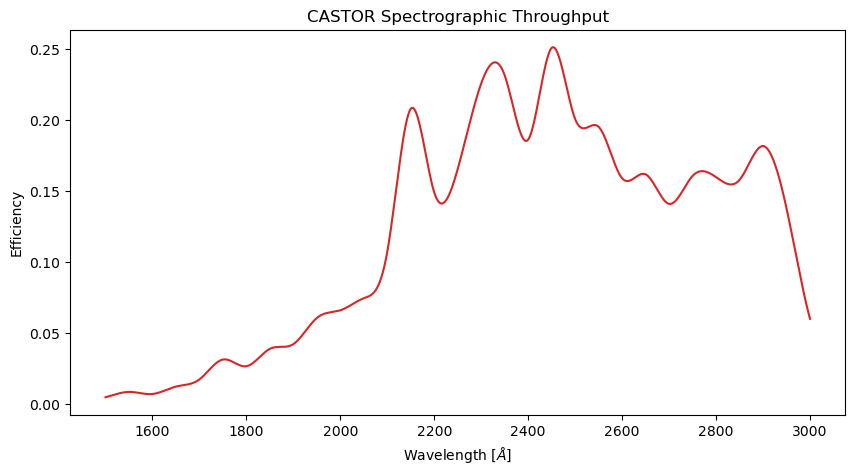

In [13]:
### Show transmission

uvmos_etc.showTransmission()

The function $\verb+showResolvingPower()+$ shows the resolving power of the UVMOS spectrograph as a function of wavelength.

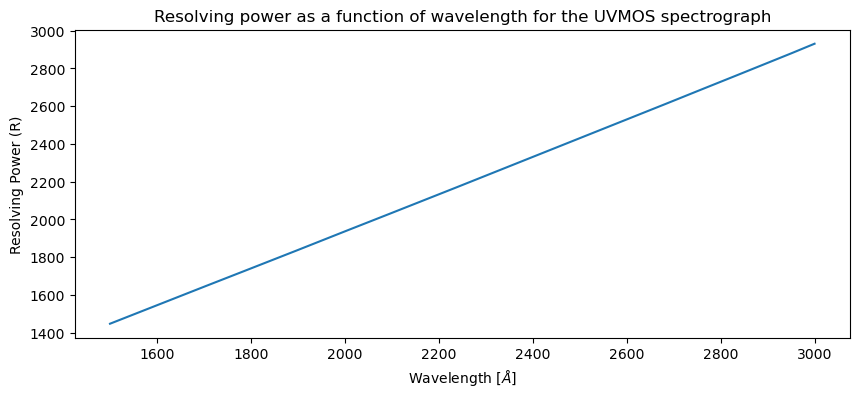

In [14]:
### Show resolving power

uvmos_etc.showResolvingPower()